# 04 — Train All Antibiotics

**Objective**: Train and evaluate **15 independent XGBoost resistance models** — one per antibiotic — using the same pipeline architecture validated on GEN in `03_Model_Training_GEN.ipynb`.

**What this notebook does:**
1. Loads `cleaned_output_v2.csv` and engineers 7 clinical risk features
2. For each of the 15 antibiotics:
   - Filters to rows with a valid lab result
   - Trains an XGBoost classifier with `scale_pos_weight` for class imbalance
   - Evaluates at the default threshold (0.50)
   - Optimizes the decision threshold using a **recall-constrained F1** strategy
3. Saves all 15 models + a unified `thresholds.json` for backend integration
4. Produces a ranked comparison and deployment-readiness analysis

**Threshold Strategy (improved):**
- Search thresholds 0.05 → 0.95
- Among thresholds achieving **Recall ≥ 0.85**, select the one with the **highest F1**
- If no threshold achieves Recall ≥ 0.85, fall back to the threshold with the **highest F2**

This prevents two failure modes:
- The old pipeline's F1 ≥ 0.40 floor (caused 0% recall for minority antibiotics)
- Pure F2 optimization (can produce thresholds like 0.06 that classify nearly everyone as resistant)

---

## 1. Imports

In [1]:
# ============================================================
# Core
# ============================================================
import pandas as pd
import numpy as np
import json
import joblib
import os
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# Visualization
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    palette="muted",
    font_scale=1.1
)

# ============================================================
# Scikit-learn — Preprocessing & Pipeline
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# ============================================================
# Scikit-learn — Metrics
# ============================================================
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score,
    fbeta_score
)

# ============================================================
# XGBoost
# ============================================================
from xgboost import XGBClassifier

print("All imports loaded successfully.")

All imports loaded successfully.


---

## 2. Configuration

In [2]:
# ============================================================
# All 15 antibiotic targets
# ============================================================
targets = [
    "AMX/AMP",
    "AMC",
    "CZ",
    "FOX",
    "CTX/CRO",
    "IPM",
    "GEN",
    "AN",
    "Acide nalidixique",
    "ofx",
    "CIP",
    "C",
    "Co-trimoxazole",
    "Furanes",
    "colistine"
]

# ============================================================
# Feature definitions (same as 03_Model_Training_GEN)
# ============================================================
features = [
    "Age",
    "Gender",
    "Souches",
    "Diabetes",
    "Hypertension",
    "Hospital_before",
    "Infection_Freq",
    "Age_Group",
    "Comorbidity_Score",
    "Hospital_Risk",
    "Frequent_Infection",
    "High_Risk_Patient",
    "Strain_Frequency",
    "Risk_Score"
]

numerical_features = [
    "Age",
    "Infection_Freq",
    "Comorbidity_Score",
    "Strain_Frequency",
    "Risk_Score"
]

categorical_features = [
    "Gender",
    "Souches",
    "Diabetes",
    "Hypertension",
    "Hospital_before",
    "Age_Group"
]

binary_features = [
    "Hospital_Risk",
    "Frequent_Infection",
    "High_Risk_Patient"
]

# ============================================================
# Reproducibility
# ============================================================
RANDOM_STATE = 42
TEST_SIZE = 0.2

# ============================================================
# Output directory
# ============================================================
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Targets:         {len(targets)} antibiotics")
print(f"Features:        {len(features)}")
print(f"Model directory: {MODEL_DIR}/")
print(f"Random state:    {RANDOM_STATE}")
print(f"Test size:       {TEST_SIZE}")

Targets:         15 antibiotics
Features:        14
Model directory: models/
Random state:    42
Test size:       0.2


---

## 3. Load Dataset

In [3]:
# ============================================================
# Load cleaned dataset
# ============================================================
df = pd.read_csv("cleaned_output_v2.csv")

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Dataset shape: (9957, 23)
Rows: 9,957  |  Columns: 23


,ID,Age,Gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,...,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine
0,S290,37.0,F,Escherichia coli,No,No,No,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,S291,29.0,F,Morganella morganii,Yes,No,No,3.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,S292,77.0,F,Proteus mirabilis,Yes,No,No,3.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,S294,13.0,F,Escherichia coli,No,Yes,No,1.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,S295,57.0,M,Escherichia coli,Yes,No,No,3.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---

## 4. Feature Engineering

Same 7 engineered features from `03_Model_Training_GEN.ipynb` — derived from base clinical columns.

In [4]:
# ============================================================
# Engineer features (identical to GEN notebook)
# ============================================================

# 1. Age Group
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 18, 40, 60, 120],
    labels=[
        "Child",
        "Young_Adult",
        "Adult",
        "Senior"
    ]
)

# 2. Comorbidity Score
df["Comorbidity_Score"] = (
    (df["Diabetes"] == "Yes").astype(int)
    +
    (df["Hypertension"] == "Yes").astype(int)
)

# 3. Hospital Risk
df["Hospital_Risk"] = (
    df["Hospital_before"] == "Yes"
).astype(int)

# 4. Frequent Infection
df["Frequent_Infection"] = (
    df["Infection_Freq"] >= 3
).astype(int)

# 5. High Risk Patient
df["High_Risk_Patient"] = (
    (
        df["Hospital_before"] == "Yes"
    )
    &
    (
        df["Infection_Freq"] >= 3
    )
).astype(int)

# 6. Strain Frequency
strain_freq = df["Souches"].value_counts()

df["Strain_Frequency"] = (
    df["Souches"].map(strain_freq)
)

# 7. Risk Score
df["Risk_Score"] = (
    (df["Diabetes"] == "Yes").astype(int)
    +
    (df["Hypertension"] == "Yes").astype(int)
    +
    (df["Hospital_before"] == "Yes").astype(int)
    +
    (df["Infection_Freq"] >= 3).astype(int)
)

print("Feature engineering complete.")
print(f"Dataset shape: {df.shape}")
print(f"\nEngineered features:")
for col in ["Age_Group", "Comorbidity_Score", "Hospital_Risk",
            "Frequent_Infection", "High_Risk_Patient",
            "Strain_Frequency", "Risk_Score"]:
    print(f"  {col:22s}  unique: {df[col].nunique()}")

Feature engineering complete.
Dataset shape: (9957, 30)

Engineered features:
  Age_Group               unique: 4
  Comorbidity_Score       unique: 3
  Hospital_Risk           unique: 2
  Frequent_Infection      unique: 2
  High_Risk_Patient       unique: 2
  Strain_Frequency        unique: 13
  Risk_Score              unique: 5


---

## 5. Target Overview

Before training, let's inspect every antibiotic's class distribution. This reveals which targets are **well-balanced** (beta-lactams, ~58% resistance) and which are **heavily imbalanced** (aminoglycosides, fluoroquinolones, ~14–20% resistance).

In [5]:
# ============================================================
# Class distribution for all 15 antibiotics
# ============================================================
overview_rows = []

for target in targets:
    valid = df[target].dropna()
    total = len(valid)
    resistant = int((valid == 1).sum())
    susceptible = int((valid == 0).sum())
    rate = 100 * resistant / total if total > 0 else 0

    overview_rows.append({
        "Antibiotic": target,
        "Total": total,
        "Resistant": resistant,
        "Susceptible": susceptible,
        "Resistance %": round(rate, 1)
    })

overview_df = pd.DataFrame(overview_rows)
print(overview_df.to_string(index=False))

       Antibiotic  Total  Resistant  Susceptible  Resistance %
          AMX/AMP   9773       5712         4061          58.4
              AMC   9785       5815         3970          59.4
               CZ   9787       5690         4097          58.1
              FOX   9784       5735         4049          58.6
          CTX/CRO   9774       5748         4026          58.8
              IPM   9771       5717         4054          58.5
              GEN   9790       1936         7854          19.8
               AN   9780       1905         7875          19.5
Acide nalidixique   9767       1388         8379          14.2
              ofx   9787       1381         8406          14.1
              CIP   9778       1447         8331          14.8
                C   9775       1385         8390          14.2
   Co-trimoxazole   9783       1413         8370          14.4
          Furanes   9783       1326         8457          13.6
        colistine   9766       1338         8428       

---

## 6. Reusable Functions

All pipeline logic is encapsulated in modular functions. This eliminates code duplication across the 15 training iterations and makes the pipeline easy to maintain.

In [6]:
def build_preprocessor():
    """
    Build a fresh ColumnTransformer preprocessor.

    A new preprocessor is created for each target because
    the fitted state (learned categories, medians) should
    be independent per antibiotic's training subset.

    Architecture (identical to 03_Model_Training_GEN):
      - Numerical:   SimpleImputer(median)
      - Categorical: SimpleImputer(most_frequent) → OneHotEncoder
      - Binary:      SimpleImputer(median)
    """
    numerical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    binary_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numerical_transformer, numerical_features),
            ("cat", categorical_transformer, categorical_features),
            ("bin", binary_transformer, binary_features)
        ]
    )

    return preprocessor


print("build_preprocessor() defined.")

build_preprocessor() defined.


In [7]:
def build_pipeline(scale_pos_weight):
    """
    Build a complete sklearn Pipeline: preprocessor + XGBClassifier.

    Hyperparameters are identical to 03_Model_Training_GEN.
    Only scale_pos_weight varies per antibiotic.
    """
    preprocessor = build_preprocessor()

    classifier = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    return pipeline


print("build_pipeline() defined.")

build_pipeline() defined.


In [8]:
def find_best_threshold(y_true, y_proba, recall_floor=0.85):
    """
    Recall-constrained threshold optimization.

    Strategy:
      1. Search thresholds from 0.05 to 0.95
      2. Among thresholds where Recall >= recall_floor:
         → select the one with the HIGHEST F1 (balances precision)
      3. If no threshold achieves recall_floor:
         → fall back to the threshold with the HIGHEST F2

    This avoids:
      - The old pipeline's F1 >= 0.40 floor (caused 0% recall)
      - Pure F2 optimization (produces thresholds like 0.06)

    Parameters
    ----------
    y_true : array-like — true binary labels
    y_proba : array-like — predicted probabilities (positive class)
    recall_floor : float — minimum acceptable recall (default 0.85)

    Returns
    -------
    dict with best_threshold, precision, recall, f1, f2, strategy
    """
    thresholds = np.arange(0.05, 0.96, 0.01)
    results = []

    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)

        if len(np.unique(y_pred)) < 2:
            prec = rec = f1 = f2 = 0.0
        else:
            prec = precision_score(y_true, y_pred, zero_division=0)
            rec  = recall_score(y_true, y_pred, zero_division=0)
            f1   = f1_score(y_true, y_pred, zero_division=0)
            f2   = fbeta_score(y_true, y_pred, beta=2, zero_division=0)

        results.append({
            "threshold": round(thresh, 2),
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "f2": f2
        })

    results_df = pd.DataFrame(results)

    # Strategy 1: Recall >= floor → highest F1
    high_recall = results_df[results_df["recall"] >= recall_floor]

    if len(high_recall) > 0:
        best_row = high_recall.loc[high_recall["f1"].idxmax()]
        strategy = f"Recall >= {recall_floor} → max F1"
    else:
        # Strategy 2: Fallback → highest F2
        best_row = results_df.loc[results_df["f2"].idxmax()]
        strategy = "Fallback → max F2"

    return {
        "best_threshold": best_row["threshold"],
        "best_precision": round(best_row["precision"], 4),
        "best_recall": round(best_row["recall"], 4),
        "best_f1": round(best_row["f1"], 4),
        "best_f2": round(best_row["f2"], 4),
        "strategy": strategy
    }


print("find_best_threshold() defined.")

find_best_threshold() defined.


In [9]:
def evaluate_default(y_true, y_pred, y_proba):
    """
    Calculate metrics at the default 0.50 threshold.

    Returns dict with precision, recall, f1, roc_auc.
    """
    return {
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_true, y_proba), 4)
    }


def sanitize_filename(name):
    """
    Convert antibiotic name to a safe filename.

    Examples:
      'AMX/AMP'           → 'AMX_AMP'
      'Acide nalidixique' → 'Acide_nalidixique'
      'Co-trimoxazole'    → 'Co-trimoxazole'
    """
    return name.replace("/", "_").replace(" ", "_")


print("evaluate_default() and sanitize_filename() defined.")

evaluate_default() and sanitize_filename() defined.


In [10]:
def train_single_antibiotic(df, target, features, verbose=True):
    """
    Full training pipeline for a single antibiotic target.

    Steps:
      1. Filter rows with valid labels
      2. Create X, y
      3. Stratified train/test split
      4. Calculate scale_pos_weight
      5. Build & fit pipeline
      6. Evaluate at default threshold (0.50)
      7. Optimize threshold (recall-constrained F1)
      8. Save model

    Parameters
    ----------
    df : DataFrame — full dataset with engineered features
    target : str — antibiotic column name
    features : list — feature column names
    verbose : bool — print progress

    Returns
    -------
    dict with all results and the fitted pipeline
    """
    # 1. Filter to valid labels
    temp = df[df[target].notna()].copy()
    total = len(temp)
    resistant = int((temp[target] == 1).sum())
    susceptible = int((temp[target] == 0).sum())
    resistance_rate = round(100 * resistant / total, 1) if total > 0 else 0

    # 2. Create X, y
    X = temp[features].copy()
    y = temp[target].astype(int).copy()

    # 3. Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        stratify=y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    # 4. Class imbalance weight
    neg_count = int((y_train == 0).sum())
    pos_count = int((y_train == 1).sum())
    spw = neg_count / max(pos_count, 1)

    # 5. Build & fit
    pipeline = build_pipeline(scale_pos_weight=spw)
    pipeline.fit(X_train, y_train)

    # 6. Default threshold evaluation
    y_pred_default = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    default_metrics = evaluate_default(y_test, y_pred_default, y_proba)

    # 7. Threshold optimization
    opt = find_best_threshold(y_test, y_proba)

    # 8. Save model
    safe_name = sanitize_filename(target)
    model_path = os.path.join(MODEL_DIR, f"{safe_name}.joblib")
    joblib.dump(pipeline, model_path)

    if verbose:
        print(
            f"  {target:20s}  "
            f"Samples={total:,}  "
            f"R%={resistance_rate:5.1f}  "
            f"ROC={default_metrics['roc_auc']:.3f}  "
            f"Thresh={opt['best_threshold']:.2f}  "
            f"F1={opt['best_f1']:.3f}  "
            f"Recall={opt['best_recall']:.3f}  "
            f"[{opt['strategy']}]"
        )

    return {
        "Antibiotic": target,
        "Samples": total,
        "Resistant_Count": resistant,
        "Susceptible_Count": susceptible,
        "Resistance_Rate": resistance_rate,
        "ROC_AUC": default_metrics["roc_auc"],
        "Default_Precision": default_metrics["precision"],
        "Default_Recall": default_metrics["recall"],
        "Default_F1": default_metrics["f1"],
        "Best_Threshold": opt["best_threshold"],
        "Optimized_Precision": opt["best_precision"],
        "Optimized_Recall": opt["best_recall"],
        "Optimized_F1": opt["best_f1"],
        "Optimized_F2": opt["best_f2"],
        "Strategy": opt["strategy"],
        "Model_Path": model_path,
        "pipeline": pipeline
    }


print("train_single_antibiotic() defined.")

train_single_antibiotic() defined.


---

## 7. Train All 15 Models

This is the main training loop. Each antibiotic gets its own:
- Filtered dataset (rows with valid lab results)
- `scale_pos_weight` tuned to its specific class balance
- Independent train/test split
- Recall-constrained threshold optimization
- Serialized model file

In [11]:
# ============================================================
# Train all 15 antibiotic models
# ============================================================
print(f"Training {len(targets)} models...")
print(f"{'=' * 110}")

all_results = []

for i, target in enumerate(targets, 1):
    print(f"[{i:2d}/{len(targets)}]", end="")
    result = train_single_antibiotic(df, target, features)
    all_results.append(result)

print(f"{'=' * 110}")
print(f"\nAll {len(targets)} models trained and saved to '{MODEL_DIR}/'")

Training 15 models...
[ 1/15]  AMX/AMP               Samples=9,773  R%= 58.4  ROC=0.665  Thresh=0.34  F1=0.757  Recall=0.889  [Recall >= 0.85 → max F1]
[ 2/15]  AMC                   Samples=9,785  R%= 59.4  ROC=0.639  Thresh=0.31  F1=0.756  Recall=0.908  [Recall >= 0.85 → max F1]
[ 3/15]  CZ                    Samples=9,787  R%= 58.1  ROC=0.656  Thresh=0.19  F1=0.749  Recall=0.984  [Recall >= 0.85 → max F1]
[ 4/15]  FOX                   Samples=9,784  R%= 58.6  ROC=0.646  Thresh=0.18  F1=0.751  Recall=0.978  [Recall >= 0.85 → max F1]
[ 5/15]  CTX/CRO               Samples=9,774  R%= 58.8  ROC=0.655  Thresh=0.23  F1=0.752  Recall=0.959  [Recall >= 0.85 → max F1]
[ 6/15]  IPM                   Samples=9,771  R%= 58.5  ROC=0.668  Thresh=0.28  F1=0.757  Recall=0.926  [Recall >= 0.85 → max F1]
[ 7/15]  GEN                   Samples=9,790  R%= 19.8  ROC=0.558  Thresh=0.19  F1=0.332  Recall=0.977  [Recall >= 0.85 → max F1]
[ 8/15]  AN                    Samples=9,780  R%= 19.5  ROC=0.562  T

---

## 8. Results Summary

Consolidated results across all 15 antibiotics, sorted by ROC-AUC descending.

In [12]:
# ============================================================
# Build results dataframe
# ============================================================
results_df = pd.DataFrame(all_results).drop(
    columns=["pipeline", "Model_Path", "Strategy"]
).sort_values(
    "ROC_AUC", ascending=False
).reset_index(drop=True)

print("Results — All 15 Antibiotics (sorted by ROC-AUC)")
print("=" * 120)
print(results_df.to_string(index=False))
print("=" * 120)

Results — All 15 Antibiotics (sorted by ROC-AUC)
       Antibiotic  Samples  Resistant_Count  Susceptible_Count  Resistance_Rate  ROC_AUC  Default_Precision  Default_Recall  Default_F1  Best_Threshold  Optimized_Precision  Optimized_Recall  Optimized_F1  Optimized_F2
              IPM     9771             5717               4054             58.5   0.6685             0.7016          0.7483      0.7242            0.28               0.6407            0.9257        0.7572        0.8501
          AMX/AMP     9773             5712               4061             58.4   0.6653             0.6940          0.7620      0.7264            0.34               0.6597            0.8889        0.7574        0.8312
               CZ     9787             5690               4097             58.1   0.6563             0.6807          0.7250      0.7021            0.19               0.6041            0.9842        0.7487        0.8742
          CTX/CRO     9774             5748               4026             

In [13]:
# ============================================================
# Threshold strategy used per antibiotic
# ============================================================
strategy_df = pd.DataFrame([
    {"Antibiotic": r["Antibiotic"],
     "Threshold": r["Best_Threshold"],
     "Strategy": r["Strategy"]}
    for r in all_results
])

print("Threshold Selection Strategy")
print("=" * 65)
print(strategy_df.to_string(index=False))
print("=" * 65)
print()
print("Strategy counts:")
print(strategy_df["Strategy"].value_counts().to_string())

Threshold Selection Strategy
       Antibiotic  Threshold                Strategy
          AMX/AMP       0.34 Recall >= 0.85 → max F1
              AMC       0.31 Recall >= 0.85 → max F1
               CZ       0.19 Recall >= 0.85 → max F1
              FOX       0.18 Recall >= 0.85 → max F1
          CTX/CRO       0.23 Recall >= 0.85 → max F1
              IPM       0.28 Recall >= 0.85 → max F1
              GEN       0.19 Recall >= 0.85 → max F1
               AN       0.22 Recall >= 0.85 → max F1
Acide nalidixique       0.24 Recall >= 0.85 → max F1
              ofx       0.28 Recall >= 0.85 → max F1
              CIP       0.33 Recall >= 0.85 → max F1
                C       0.30 Recall >= 0.85 → max F1
   Co-trimoxazole       0.24 Recall >= 0.85 → max F1
          Furanes       0.25 Recall >= 0.85 → max F1
        colistine       0.31 Recall >= 0.85 → max F1

Strategy counts:
Strategy
Recall >= 0.85 → max F1    15


---

## 9. Visualizations

### 9.1 ROC-AUC Ranking

ROC-AUC measures the model's ability to **distinguish** between Resistant and Susceptible, independent of the decision threshold. Higher = better discrimination.

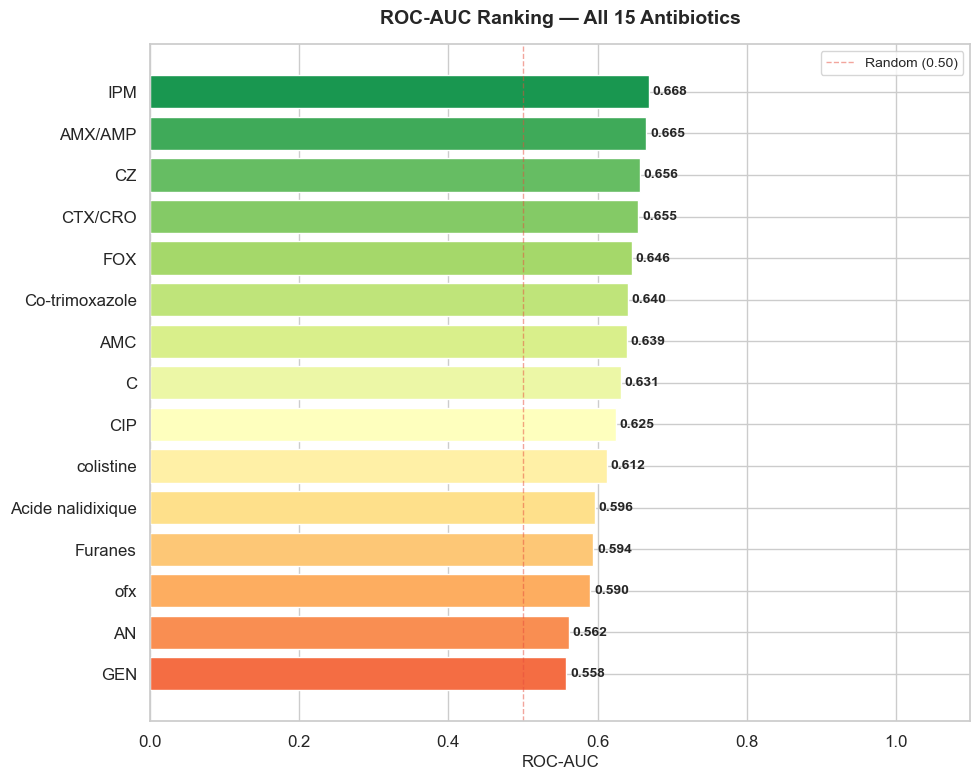

In [14]:
# ============================================================
# ROC-AUC Ranking — horizontal bar chart
# ============================================================
plot_data = results_df.sort_values("ROC_AUC", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(plot_data))
)

bars = ax.barh(
    plot_data["Antibiotic"],
    plot_data["ROC_AUC"],
    color=colors,
    edgecolor="white", linewidth=1
)

for bar in bars:
    w = bar.get_width()
    ax.text(
        w + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.3f}",
        ha="left", va="center",
        fontsize=10, fontweight="bold"
    )

ax.set_xlabel("ROC-AUC", fontsize=12)
ax.set_title(
    "ROC-AUC Ranking — All 15 Antibiotics",
    fontsize=14, fontweight="bold", pad=15
)
ax.set_xlim(0, 1.1)
ax.axvline(x=0.5, color="#e74c3c", linestyle="--",
           linewidth=1, alpha=0.5, label="Random (0.50)")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### 9.2 Optimized F1 Ranking

F1 at the optimized threshold shows each model's **deployed performance** — the balance between precision and recall after threshold tuning.

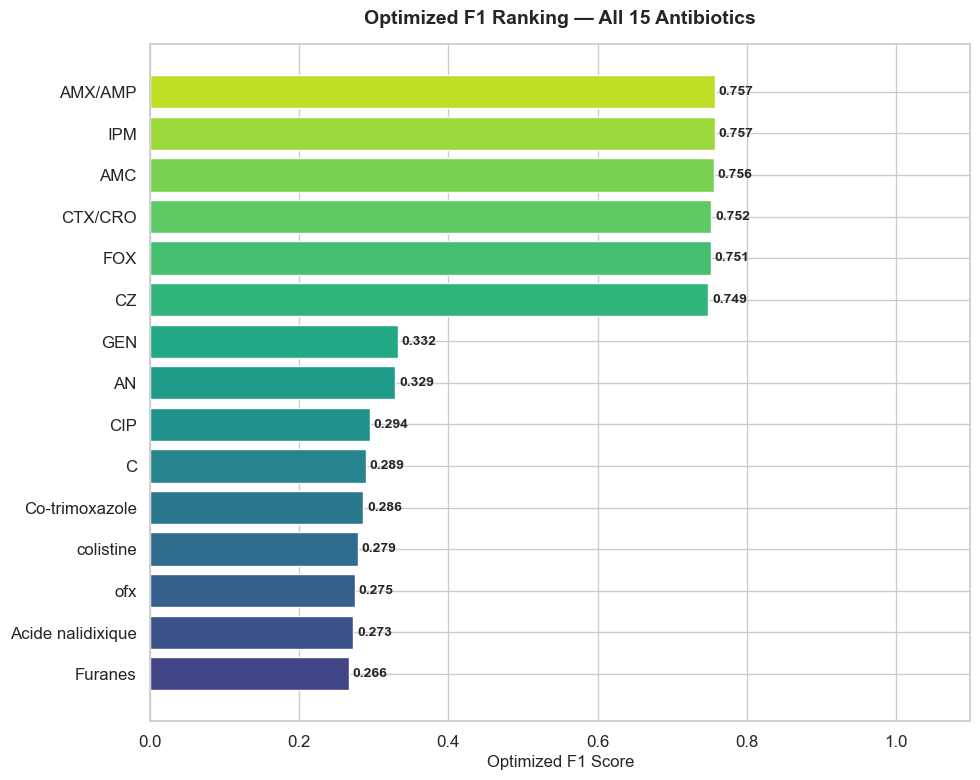

In [15]:
# ============================================================
# F1 Score Ranking — horizontal bar chart
# ============================================================
plot_data = results_df.sort_values("Optimized_F1", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(plot_data))
)

bars = ax.barh(
    plot_data["Antibiotic"],
    plot_data["Optimized_F1"],
    color=colors,
    edgecolor="white", linewidth=1
)

for bar in bars:
    w = bar.get_width()
    ax.text(
        w + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.3f}",
        ha="left", va="center",
        fontsize=10, fontweight="bold"
    )

ax.set_xlabel("Optimized F1 Score", fontsize=12)
ax.set_title(
    "Optimized F1 Ranking — All 15 Antibiotics",
    fontsize=14, fontweight="bold", pad=15
)
ax.set_xlim(0, 1.1)

plt.tight_layout()
plt.show()

### 9.3 Resistance Rate Distribution

Baseline resistance rate determines model difficulty — highly imbalanced targets (low %) are inherently harder to predict.

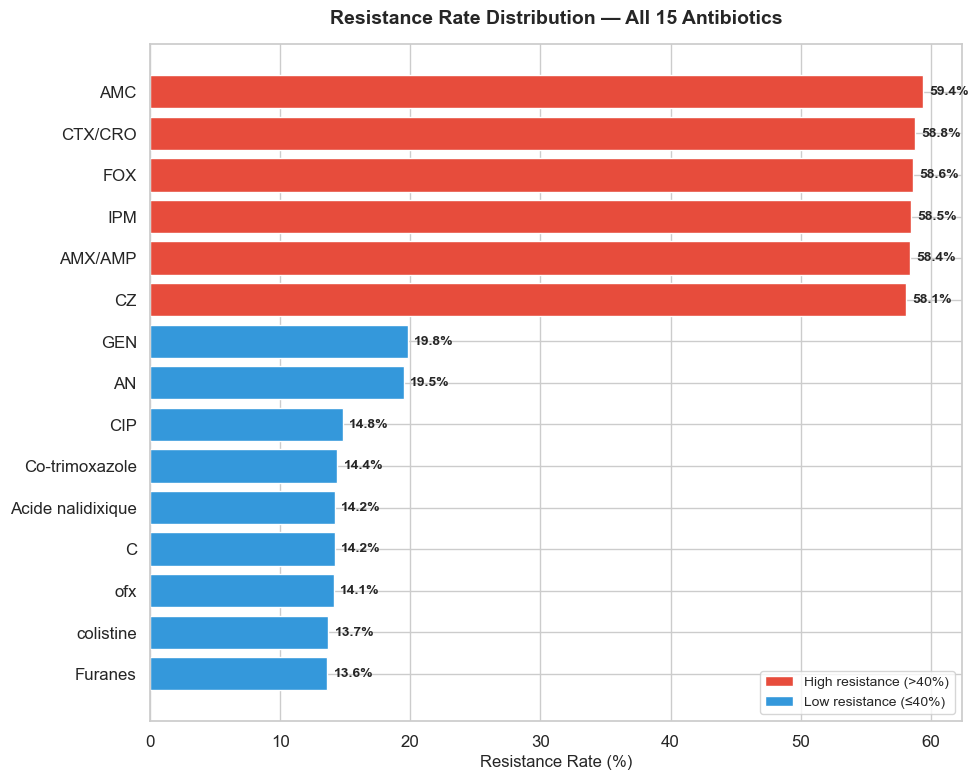

In [16]:
# ============================================================
# Resistance Rate — bar chart
# ============================================================
plot_data = results_df.sort_values("Resistance_Rate", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

# Color by group: high resistance (>40%) vs low resistance
bar_colors = [
    "#e74c3c" if rate > 40 else "#3498db"
    for rate in plot_data["Resistance_Rate"]
]

bars = ax.barh(
    plot_data["Antibiotic"],
    plot_data["Resistance_Rate"],
    color=bar_colors,
    edgecolor="white", linewidth=1
)

for bar in bars:
    w = bar.get_width()
    ax.text(
        w + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.1f}%",
        ha="left", va="center",
        fontsize=10, fontweight="bold"
    )

ax.set_xlabel("Resistance Rate (%)", fontsize=12)
ax.set_title(
    "Resistance Rate Distribution — All 15 Antibiotics",
    fontsize=14, fontweight="bold", pad=15
)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e74c3c", label="High resistance (>40%)"),
    Patch(facecolor="#3498db", label="Low resistance (≤40%)")
]
ax.legend(handles=legend_elements, fontsize=10, loc="lower right")

plt.tight_layout()
plt.show()

---

## 10. Save Thresholds

Save a unified `thresholds.json` mapping each antibiotic to its optimized decision threshold. The FastAPI backend loads this file to apply the correct threshold during inference.

In [17]:
# ============================================================
# Save thresholds.json
# ============================================================
thresholds_dict = {
    r["Antibiotic"]: r["Best_Threshold"]
    for r in all_results
}

thresholds_path = "thresholds.json"

with open(thresholds_path, "w") as f:
    json.dump(thresholds_dict, f, indent=2)

print(f"Thresholds saved: {thresholds_path}")
print()
print(json.dumps(thresholds_dict, indent=2))

Thresholds saved: thresholds.json

{
  "AMX/AMP": 0.34,
  "AMC": 0.31,
  "CZ": 0.19,
  "FOX": 0.18,
  "CTX/CRO": 0.23,
  "IPM": 0.28,
  "GEN": 0.19,
  "AN": 0.22,
  "Acide nalidixique": 0.24,
  "ofx": 0.28,
  "CIP": 0.33,
  "C": 0.3,
  "Co-trimoxazole": 0.24,
  "Furanes": 0.25,
  "colistine": 0.31
}


In [18]:
# ============================================================
# Save results CSV for external analysis
# ============================================================
results_path = "training_results.csv"
results_df.to_csv(results_path, index=False)

print(f"Results table saved: {results_path}")

Results table saved: training_results.csv


In [19]:
# ============================================================
# List saved model files
# ============================================================
print(f"Saved models in '{MODEL_DIR}/':\n")

for fname in sorted(os.listdir(MODEL_DIR)):
    if fname.endswith(".joblib"):
        fpath = os.path.join(MODEL_DIR, fname)
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {fname:30s}  {size_kb:7.1f} KB")

Saved models in 'models/':

  AMC.joblib                        703.9 KB
  AMX_AMP.joblib                    719.7 KB
  AN.joblib                         734.6 KB
  Acide_nalidixique.joblib          689.2 KB
  C.joblib                          678.8 KB
  CIP.joblib                        691.6 KB
  CTX_CRO.joblib                    712.9 KB
  CZ.joblib                         715.0 KB
  Co-trimoxazole.joblib             686.3 KB
  FOX.joblib                        723.6 KB
  Furanes.joblib                    670.3 KB
  GEN.joblib                        722.0 KB
  IPM.joblib                        719.4 KB
  colistine.joblib                  675.2 KB
  ofx.joblib                        700.5 KB


---

## 11. Final Analysis

### 11.1 Best & Weakest Performing Antibiotics

In [20]:
# ============================================================
# Top 5 by ROC-AUC
# ============================================================
sorted_by_auc = results_df.sort_values("ROC_AUC", ascending=False)

print("BEST PERFORMING ANTIBIOTICS (Top 5 by ROC-AUC)")
print("=" * 70)
top5 = sorted_by_auc.head(5)[["Antibiotic", "ROC_AUC", "Optimized_F1",
                               "Optimized_Recall", "Best_Threshold"]]
print(top5.to_string(index=False))

print()

print("WEAKEST PERFORMING ANTIBIOTICS (Bottom 5 by ROC-AUC)")
print("=" * 70)
bottom5 = sorted_by_auc.tail(5)[["Antibiotic", "ROC_AUC", "Optimized_F1",
                                  "Optimized_Recall", "Best_Threshold"]]
print(bottom5.to_string(index=False))

BEST PERFORMING ANTIBIOTICS (Top 5 by ROC-AUC)
Antibiotic  ROC_AUC  Optimized_F1  Optimized_Recall  Best_Threshold
       IPM   0.6685        0.7572            0.9257            0.28
   AMX/AMP   0.6653        0.7574            0.8889            0.34
        CZ   0.6563        0.7487            0.9842            0.19
   CTX/CRO   0.6549        0.7524            0.9591            0.23
       FOX   0.6456        0.7515            0.9782            0.18

WEAKEST PERFORMING ANTIBIOTICS (Bottom 5 by ROC-AUC)
       Antibiotic  ROC_AUC  Optimized_F1  Optimized_Recall  Best_Threshold
Acide nalidixique   0.5964        0.2726            0.8525            0.24
          Furanes   0.5942        0.2664            0.8566            0.25
              ofx   0.5902        0.2747            0.8551            0.28
               AN   0.5616        0.3288            0.9738            0.22
              GEN   0.5583        0.3320            0.9767            0.19


### 11.2 Summary Statistics

In [21]:
# ============================================================
# Summary statistics
# ============================================================
avg_roc  = results_df["ROC_AUC"].mean()
avg_f1   = results_df["Optimized_F1"].mean()
best_roc = results_df["ROC_AUC"].max()
worst_roc = results_df["ROC_AUC"].min()

best_ab  = results_df.loc[results_df["ROC_AUC"].idxmax(), "Antibiotic"]
worst_ab = results_df.loc[results_df["ROC_AUC"].idxmin(), "Antibiotic"]

print("SUMMARY STATISTICS")
print("=" * 50)
print(f"  Average ROC-AUC:   {avg_roc:.4f}")
print(f"  Average F1:        {avg_f1:.4f}")
print(f"  Best ROC-AUC:      {best_roc:.4f}  ({best_ab})")
print(f"  Worst ROC-AUC:     {worst_roc:.4f}  ({worst_ab})")
print(f"  ROC-AUC Std Dev:   {results_df['ROC_AUC'].std():.4f}")
print("=" * 50)

SUMMARY STATISTICS
  Average ROC-AUC:   0.6226
  Average F1:        0.4763
  Best ROC-AUC:      0.6685  (IPM)
  Worst ROC-AUC:     0.5583  (GEN)
  ROC-AUC Std Dev:   0.0357


### 11.3 Deployment Readiness Recommendations

In [22]:
# ============================================================
# Classify antibiotics by deployment readiness
#
# Tiers based on ROC-AUC:
#   >= 0.70  →  Ready for deployment
#   >= 0.60  →  Deploy with confidence warnings
#   <  0.60  →  Needs improvement before deployment
# ============================================================

def classify_readiness(row):
    """Classify deployment readiness based on ROC-AUC."""
    if row["ROC_AUC"] >= 0.70:
        return "READY — Reliable for deployment"
    elif row["ROC_AUC"] >= 0.60:
        return "CAUTION — Deploy with confidence warnings"
    else:
        return "NEEDS WORK — Requires additional features/data"


results_df["Deployment_Status"] = results_df.apply(
    classify_readiness, axis=1
)

print("DEPLOYMENT READINESS ASSESSMENT")
print("=" * 85)

for status in [
    "READY — Reliable for deployment",
    "CAUTION — Deploy with confidence warnings",
    "NEEDS WORK — Requires additional features/data"
]:
    group = results_df[results_df["Deployment_Status"] == status]
    if len(group) > 0:
        print(f"\n{status}  ({len(group)} antibiotics)")
        print("-" * 70)
        for _, row in group.iterrows():
            print(
                f"  {row['Antibiotic']:22s}  "
                f"ROC={row['ROC_AUC']:.3f}  "
                f"F1={row['Optimized_F1']:.3f}  "
                f"Recall={row['Optimized_Recall']:.3f}  "
                f"Thresh={row['Best_Threshold']:.2f}"
            )

print(f"\n{'=' * 85}")

DEPLOYMENT READINESS ASSESSMENT

CAUTION — Deploy with confidence warnings  (10 antibiotics)
----------------------------------------------------------------------
  IPM                     ROC=0.668  F1=0.757  Recall=0.926  Thresh=0.28
  AMX/AMP                 ROC=0.665  F1=0.757  Recall=0.889  Thresh=0.34
  CZ                      ROC=0.656  F1=0.749  Recall=0.984  Thresh=0.19
  CTX/CRO                 ROC=0.655  F1=0.752  Recall=0.959  Thresh=0.23
  FOX                     ROC=0.646  F1=0.751  Recall=0.978  Thresh=0.18
  Co-trimoxazole          ROC=0.640  F1=0.286  Recall=0.880  Thresh=0.24
  AMC                     ROC=0.639  F1=0.756  Recall=0.908  Thresh=0.31
  C                       ROC=0.631  F1=0.289  Recall=0.852  Thresh=0.30
  CIP                     ROC=0.625  F1=0.294  Recall=0.851  Thresh=0.33
  colistine               ROC=0.612  F1=0.279  Recall=0.851  Thresh=0.31

NEEDS WORK — Requires additional features/data  (5 antibiotics)
-----------------------------------------

In [23]:
# ============================================================
# Recommendations summary
# ============================================================
ready = results_df[results_df["ROC_AUC"] >= 0.70]
caution = results_df[(results_df["ROC_AUC"] >= 0.60) & (results_df["ROC_AUC"] < 0.70)]
needs_work = results_df[results_df["ROC_AUC"] < 0.60]

print("RECOMMENDATIONS")
print("=" * 70)
print()

if len(ready) > 0:
    print(f"1. DEPLOY IMMEDIATELY ({len(ready)} antibiotics):")
    print(f"   {', '.join(ready['Antibiotic'].values)}")
    print(f"   These models have ROC-AUC >= 0.70 and can be")
    print(f"   served by the FastAPI backend with high confidence.")
    print()

if len(caution) > 0:
    print(f"2. DEPLOY WITH WARNINGS ({len(caution)} antibiotics):")
    print(f"   {', '.join(caution['Antibiotic'].values)}")
    print(f"   Show a confidence warning in the UI. Predictions")
    print(f"   are informative but should not override clinical judgment.")
    print()

if len(needs_work) > 0:
    print(f"3. NEEDS IMPROVEMENT ({len(needs_work)} antibiotics):")
    print(f"   {', '.join(needs_work['Antibiotic'].values)}")
    print(f"   These models may require:")
    print(f"   - Additional clinical features (specimen source, Gram stain)")
    print(f"   - More training data with confirmed resistance labels")
    print(f"   - Alternative model architectures (ensemble, neural network)")
    print(f"   Consider hiding these from the UI or marking as 'experimental'.")

print()
print("=" * 70)

RECOMMENDATIONS

2. DEPLOY WITH WARNINGS (10 antibiotics):
   IPM, AMX/AMP, CZ, CTX/CRO, FOX, Co-trimoxazole, AMC, C, CIP, colistine
   Show a confidence warning in the UI. Predictions
   are informative but should not override clinical judgment.

3. NEEDS IMPROVEMENT (5 antibiotics):
   Acide nalidixique, Furanes, ofx, AN, GEN
   These models may require:
   - Additional clinical features (specimen source, Gram stain)
   - More training data with confirmed resistance labels
   - Alternative model architectures (ensemble, neural network)
   Consider hiding these from the UI or marking as 'experimental'.



---

## Summary

### What was produced

| Artifact | Description |
|---|---|
| `models/*.joblib` | 15 trained sklearn Pipelines (preprocessor + XGBoost) |
| `thresholds.json` | Optimized decision thresholds for all 15 antibiotics |
| `training_results.csv` | Full metrics table for external analysis |

### Key design decisions

| Decision | Rationale |
|---|---|
| **Recall ≥ 0.85 → max F1** threshold strategy | Ensures high sensitivity while preventing threshold collapse |
| **Fallback to max F2** when recall floor can't be met | Graceful degradation for difficult targets |
| **Independent models per antibiotic** | Each target has different class balance and resistance patterns |
| **Per-target `scale_pos_weight`** | Class imbalance handling tuned to each antibiotic's specific ratio |

### Next steps
1. Integrate `models/` and `thresholds.json` into the FastAPI backend
2. Update the backend's prediction logic to load individual models
3. Add confidence warnings for lower-performing antibiotics in the frontend
4. Collect additional clinical features for antibiotics in the "needs work" tier